Reto: "Predicción de Fallos en Equipos en Plantas Energéticas a 15 días vista"
Objetivo del Reto:
Evolucionar la solución para desarrollar un modelo analítico predictivo que permita anticipar fallos a 15 días vista en los equipos de la planta energética con una precisión mínima del 80% (accuracy ≥ 0.80) y por lo menos un 0.75 de f1.

Por un lado se quiere predecir las horas operativas que tendrá un equipo en los próximos 15 días, de cara a considerar su mantenimiento conforme a las horas recomendadas de revisión.
Por otro lado, se quiere evaluar si una máquina fallará en los próximos 15 días, con un 80% de fiabilidad.
Evalúa la robustés del modelo en el tiempo.

Para lograr esto, deberéis:

Mezclar y preprocesar los datos de los 3 datasets proporcionados, teniendo en cuenta la componente temporal.
Seleccionar variables relevantes y generar nuevas características si es necesario. Considera usar PCA para reducir dimensiones (conservando 95% de la varianza).
Construir y evaluar múltiples modelos predictivos, que inclyan forecasting y comparando su rendimiento.
Ajustar hiperparámetros y optimizar el modelo para alcanzar la precisión deseada.
Documentar los hallazgos y justificar la elección del mejor modelo.
Bonus 1: Encontrar patrones de fallos
Usa K-Means o DBSCAN para agrupar los equipos según sus condiciones operativas y comportamiento previo a los fallos.
Incluye las siguientes características para el clustering:
Promedio de temperatura y vibración por equipo.
Desviación estándar de temperatura y vibración.
Horas operativas acumuladas promedio.
Visualiza los clusters utilizando gráficos de dispersión o mapas de calor.
Interpreta los resultados: ¿Qué patrones emergen? ¿Hay grupos de equipos más propensos a fallar?


#### *Se cargan los tres datasets y se muestran las primeras filas*

In [58]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import io
import sys
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [47]:
# Cargar los tres datasets
caracteristicas_df = pd.read_csv("../src/Caracteristicas_Equipos.csv")
ordenes_df = pd.read_csv("../src/Historicos_Ordenes.csv")
condiciones_df = pd.read_csv("../src/Registros_Condiciones.csv")

# Mostrar las primeras filas de cada dataset para revisar su estructura
# Mostrar características
display(Markdown("### 🛠️ Características de Equipos"))
display(caracteristicas_df.head())

# Mostrar órdenes históricas
display(Markdown("### 📋 Históricos de Órdenes"))
display(ordenes_df.head())

# Mostrar condiciones operativas
display(Markdown("### 📊 Registros de Condiciones"))
display(condiciones_df.head())


### 🛠️ Características de Equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Bomba,Fabricante_A,Modelo_8,432,657
1,2,Generador,Fabricante_B,Modelo_2,393,522
2,3,Motor,Fabricante_C,Modelo_7,398,885
3,4,Bomba,Fabricante_D,Modelo_4,121,668
4,5,Generador,Fabricante_C,Modelo_7,51,958


### 📋 Históricos de Órdenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B


### 📊 Registros de Condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,1,2021-01-01,36.587104,4.430381,579
1,2,106,2021-01-01,53.268051,0.534711,577
2,3,446,2021-01-01,47.176472,7.116958,263
3,4,107,2021-01-01,76.404597,2.696906,491
4,5,108,2021-01-01,50.729327,6.996772,589


In [48]:
def print_info(df, titulo):
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    display(Markdown(f"### {titulo}"))
    display(Markdown(f"```\n{info_str}\n```"))

# Mostrar info de cada DataFrame
print_info(caracteristicas_df, "🛠️ Info: Características de Equipos")
print_info(ordenes_df, "📋 Info: Históricos de Órdenes")
print_info(condiciones_df, "📊 Info: Registros de Condiciones")


### 🛠️ Info: Características de Equipos

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    500 non-null    int64 
 1   Tipo_Equipo                  500 non-null    object
 2   Fabricante                   500 non-null    object
 3   Modelo                       500 non-null    object
 4   Potencia_kW                  500 non-null    int64 
 5   Horas_Recomendadas_Revision  500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB

```

### 📋 Info: Históricos de Órdenes

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Orden             31866 non-null  int64 
 1   ID_Equipo            31866 non-null  int64 
 2   Fecha                31866 non-null  object
 3   Tipo_Mantenimiento   31866 non-null  object
 4   Costo_Mantenimiento  31866 non-null  int64 
 5   Duracion_Horas       31866 non-null  int64 
 6   Ubicacion            31866 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.7+ MB

```

### 📊 Info: Registros de Condiciones

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID_Registro       730500 non-null  int64  
 1   ID_Equipo         730500 non-null  int64  
 2   Fecha             730500 non-null  object 
 3   Temperatura_C     730500 non-null  float64
 4   Vibracion_mm_s    730500 non-null  float64
 5   Horas_Operativas  730500 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 33.4+ MB

```

#### *Merge de los tres dataframes con las variables que suponemos más importantes*

In [69]:
def cargar_combinar_y_rellenar(path_caract, path_ordenes, path_condiciones):
    # Cargar y seleccionar columnas
    caracteristicas_df = pd.read_csv(path_caract)[['ID_Equipo', 'Potencia_kW', 'Horas_Recomendadas_Revision']].copy()
    ordenes_df = pd.read_csv(path_ordenes)[['ID_Equipo', 'Fecha', 'Tipo_Mantenimiento', 'Costo_Mantenimiento', 'Duracion_Horas']].copy()
    condiciones_df = pd.read_csv(path_condiciones)[['ID_Equipo', 'Fecha', 'Temperatura_C', 'Vibracion_mm_s', 'Horas_Operativas']].copy()

    # Convertir fechas
    ordenes_df['Fecha'] = pd.to_datetime(ordenes_df['Fecha'])
    condiciones_df['Fecha'] = pd.to_datetime(condiciones_df['Fecha'])

    # Unir condiciones + órdenes
    condiciones_ordenes_df = pd.merge(condiciones_df, ordenes_df, on=['ID_Equipo', 'Fecha'], how='left')
    
    # Unir con características
    df_final = pd.merge(condiciones_ordenes_df, caracteristicas_df, on='ID_Equipo', how='left')

    # Mostrar nulos antes del reemplazo
    print("Valores nulos antes del reemplazo:\n", df_final.isnull().sum())

    # Reemplazar nulos numéricos con la media
    for col in df_final.select_dtypes(include='number').columns:
        df_final[col] = df_final[col].fillna(df_final[col].mean())

    # Reemplazar valores nulos en Tipo_Mantenimiento con valores aleatorios
    if 'Tipo_Mantenimiento' in df_final.columns:
        valores_existentes = df_final['Tipo_Mantenimiento'].dropna().unique()
        n_nulos = df_final['Tipo_Mantenimiento'].isnull().sum()
        df_final.loc[df_final['Tipo_Mantenimiento'].isnull(), 'Tipo_Mantenimiento'] = np.random.choice(
            valores_existentes, size=n_nulos, replace=True
        )
        # Mapear a valores numéricos: Correctivo=1, Preventivo=0
        df_final['Tipo_Mantenimiento'] = df_final['Tipo_Mantenimiento'].map({'Correctivo': 1, 'Preventivo': 0})

    # Crear nueva columna: horas_hasta_correctivo
    df_final['horas_hasta_correctivo'] = df_final['Horas_Recomendadas_Revision'] - df_final['Horas_Operativas']

    # Extraer componentes de fecha
    df_final['Dia'] = df_final['Fecha'].dt.day
    df_final['Quincena'] = df_final['Fecha'].dt.day.apply(lambda x: (x - 1) // 15 + 1)
    df_final['Mes'] = df_final['Fecha'].dt.month
    df_final['Año'] = df_final['Fecha'].dt.year

    # Mostrar nulos después del reemplazo
    print("\nValores nulos después del reemplazo:\n", df_final.isnull().sum())

    return df_final


#### *Dataframe montado, sustituyendo nulos por medias en columnas numéricas, y valores aleatorios en columna categórica, convertimos la columna Tipo_Mantenimiento en numérica siendo Correctivo=1 y Preventivo=0. También creamos columnas Día, Quincena, Mes y Año que son útiles para análisis estacionales o agrupaciones por periodos*

In [70]:
df = cargar_combinar_y_rellenar(
    "../src/Caracteristicas_Equipos.csv",
    "../src/Historicos_Ordenes.csv",
    "../src/Registros_Condiciones.csv"
)

display(df)

Valores nulos antes del reemplazo:
 ID_Equipo                           0
Fecha                               0
Temperatura_C                       0
Vibracion_mm_s                      0
Horas_Operativas                    0
Tipo_Mantenimiento             698871
Costo_Mantenimiento            698871
Duracion_Horas                 698871
Potencia_kW                         0
Horas_Recomendadas_Revision         0
dtype: int64

Valores nulos después del reemplazo:
 ID_Equipo                      0
Fecha                          0
Temperatura_C                  0
Vibracion_mm_s                 0
Horas_Operativas               0
Tipo_Mantenimiento             0
Costo_Mantenimiento            0
Duracion_Horas                 0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
horas_hasta_correctivo         0
Dia                            0
Quincena                       0
Mes                            0
Año                            0
dtype: int64


,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Potencia_kW,Horas_Recomendadas_Revision,horas_hasta_correctivo,Dia,Quincena,Mes,Año
0,1,2021-01-01,36.587104,4.430381,579,0,1042.227013,3.978755,432,657,78,1,1,1,2021
1,106,2021-01-01,53.268051,0.534711,577,0,1042.227013,3.978755,448,801,224,1,1,1,2021
2,446,2021-01-01,47.176472,7.116958,263,0,1042.227013,3.978755,95,561,298,1,1,1,2021
3,107,2021-01-01,76.404597,2.696906,491,0,1042.227013,3.978755,195,748,257,1,1,1,2021
4,108,2021-01-01,50.729327,6.996772,589,1,1042.227013,3.978755,181,560,-29,1,1,1,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730732,339,2024-12-31,65.517980,8.012958,2766,0,1042.227013,3.978755,240,688,-2078,31,3,12,2024
730733,340,2024-12-31,25.871962,0.574021,85,1,1042.227013,3.978755,263,563,478,31,3,12,2024
730734,341,2024-12-31,25.954532,3.659365,424,0,1042.227013,3.978755,326,845,421,31,3,12,2024
730735,328,2024-12-31,26.745865,7.344057,15,0,1042.227013,3.978755,337,668,653,31,3,12,2024


#### *Comprobamos que no tenemos duplicados o nulos después de tantos cambios.*

In [73]:
# Valores nulos por columna
print("Valores nulos por columna:\n", df.isnull().sum())

# Filas duplicadas (completas)
duplicados = df.duplicated()
print(f"\nNúmero de filas duplicadas: {duplicados.sum()}")


Valores nulos por columna:
 ID_Equipo                      0
Fecha                          0
Temperatura_C                  0
Vibracion_mm_s                 0
Horas_Operativas               0
Tipo_Mantenimiento             0
Costo_Mantenimiento            0
Duracion_Horas                 0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
horas_hasta_correctivo         0
Dia                            0
Quincena                       0
Mes                            0
Año                            0
dtype: int64

Número de filas duplicadas: 0


### Explicación paso a paso:

1. **`groupby([...])`**:
   Agrupa el DataFrame `info_equipos` según:
   - `ID_Equipo`: cada máquina o equipo.
   - `Potencia_kW`, `Horas_Recomendadas_Revision`: atributos técnicos del equipo.
   - `Tipo_Mantenimiento`: si fue correctivo (1) o preventivo (0).
   - `Quincena`: primera o segunda mitad del mes.

2. **`.agg({...})`**:
   Aplica funciones de agregación específicas a las columnas numéricas:
   - `'Costo_Mantenimiento': 'sum'` → suma el coste de mantenimientos en cada grupo.
   - `'Temperatura_C': 'max'` → toma la temperatura máxima de ese periodo.
   - `'Vibracion_mm_s': 'max'` → lo mismo para la vibración.
   - `'Horas_Operativas': 'mean'` → promedio de horas trabajadas en esa quincena.
   - `'horas_hasta_correctivo': 'mean'` → promedio del margen hasta revisión recomendada.

3. **`.reset_index()`**:
   Convierte los índices de agrupación de nuevo en columnas.

In [83]:
def agregar_por_quincena(df):
    """
    Agrupa los datos por equipo, tipo de mantenimiento y quincena,
    aplicando funciones de agregación específicas.
    """
    agrupado = df.groupby([
        'ID_Equipo',
        'Potencia_kW',
        'Horas_Recomendadas_Revision',
        'Tipo_Mantenimiento',
        'Quincena'
    ]).agg({
        'Costo_Mantenimiento': 'sum',
        'Temperatura_C': 'max',
        'Vibracion_mm_s': 'max',
        'Horas_Operativas': 'mean',
        'horas_hasta_correctivo': 'mean'
    }).reset_index()

    return agrupado


In [84]:
Datos_agregados = agregar_por_quincena(df)
display(Datos_agregados)

,ID_Equipo,Potencia_kW,Horas_Recomendadas_Revision,Tipo_Mantenimiento,Quincena,Costo_Mantenimiento,Temperatura_C,Vibracion_mm_s,Horas_Operativas,horas_hasta_correctivo
0,1,432,657,0,1,385842.043683,99.892595,9.970273,1291.575521,-634.575521
1,1,432,657,0,2,382545.135630,99.608395,9.976018,1279.175853,-622.175853
2,1,432,657,0,3,10422.270131,92.429857,9.314590,1035.100000,-378.100000
3,1,432,657,1,1,359625.595368,99.998314,9.982758,1192.338279,-535.338279
4,1,432,657,1,2,350177.006276,99.897962,9.976351,1201.659639,-544.659639
...,...,...,...,...,...,...,...,...,...,...
2995,500,299,710,0,2,369719.184460,99.828832,9.986717,834.395095,-124.395095
2996,500,299,710,0,3,15633.405197,94.985150,8.497106,838.133333,-128.133333
2997,500,299,710,1,1,393570.362644,99.703751,9.964977,826.294766,-116.294766
2998,500,299,710,1,2,381742.049394,99.799420,9.997947,899.670520,-189.670520


Paso 1: Calcular correlaciones: Vamos a usar `.corr()` de pandas, que calcula la correlación de Pearson entre columnas numéricas.

Paso 2: Extraer correlación con la variable objetivo

Paso 3: Visualizar con heatmap (matplotlib + seaborn)

In [87]:
correlation_matrix = Datos_agregados.corr()
print(correlation_matrix['Tipo_Mantenimiento'].sort_values(ascending=False))

Tipo_Mantenimiento             1.000000e+00
horas_hasta_correctivo         1.404619e-02
Costo_Mantenimiento            1.013640e-02
ID_Equipo                      6.124613e-16
Potencia_kW                    1.834098e-17
Quincena                       2.991428e-18
Horas_Recomendadas_Revision   -2.112127e-17
Horas_Operativas              -1.473358e-02
Temperatura_C                 -1.766694e-02
Vibracion_mm_s                -2.500560e-02
Name: Tipo_Mantenimiento, dtype: float64


In [85]:
def mostrar_correlaciones(Datos_agregados, objetivo='Tipo_Mantenimiento'):
    # Correlación entre variables numéricas
    corr_matrix = Datos_agregados.corr(numeric_only=True)

    # Extraemos correlaciones con respecto al objetivo
    correlaciones_objetivo = corr_matrix[[objetivo]].drop(index=objetivo).sort_values(by=objetivo, ascending=False)
    correlaciones_objetivo = correlaciones_objetivo.round(3)

    # Mostrar tabla ordenada
    display(correlaciones_objetivo)

    # Mapa de calor de todas las correlaciones
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Mapa de calor de correlaciones")
    plt.tight_layout()
    plt.show()


,Tipo_Mantenimiento
horas_hasta_correctivo,0.014
Costo_Mantenimiento,0.010
ID_Equipo,0.000
Potencia_kW,0.000
Quincena,0.000
Horas_Recomendadas_Revision,-0.000
Horas_Operativas,-0.015
Temperatura_C,-0.018
Vibracion_mm_s,-0.025


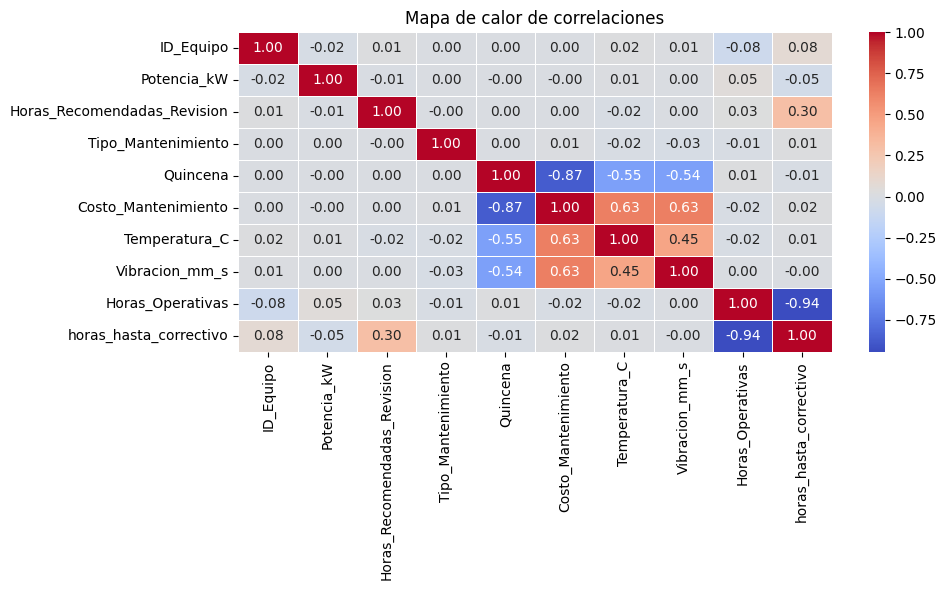

In [86]:
mostrar_correlaciones(Datos_agregados)